In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

Simulate Data:

In [9]:
def simulate_data(n_samples=800, n_covs=4):
    np.random.seed(0)
    X = np.random.normal(size=(n_samples, n_covs))

    beta1 = np.random.randn(n_covs)
    beta2 = np.random.randn(n_covs)

    lambda12 = np.exp(X @ beta1)
    lambda13 = np.exp(X @ beta2)

    T1 = np.random.exponential(1 / lambda12)
    T2 = np.random.exponential(1 / lambda13)

    TIME = np.minimum(T1, T2)
    state = (T2 < T1).astype(int) + 1

    return X, TIME, state

X, TIME, state = simulate_data()

X = torch.tensor(X, dtype=torch.float32)
TIME = torch.tensor(TIME, dtype=torch.float32)
state = torch.tensor(state, dtype=torch.int64)

Models: (Constant, Linear, NN)

In [10]:
# Constant Model
class ConstantModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_lambda12 = nn.Parameter(torch.tensor(0.0))
        self.log_lambda13 = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        l12 = torch.exp(self.log_lambda12)
        l13 = torch.exp(self.log_lambda13)
        return l12.expand(x.shape[0]), l13.expand(x.shape[0])

# Linear Model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, 1)
        self.linear2 = nn.Linear(input_dim, 1)

    def forward(self, x):
        l12 = torch.exp(self.linear1(x)).squeeze()
        l13 = torch.exp(self.linear2(x)).squeeze()
        return l12, l13

# Neural Network Model
class NNModel(nn.Module):
    def __init__(self, input_dim, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        self.head1 = nn.Linear(hidden, 1)
        self.head2 = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        l12 = torch.exp(self.head1(h)).squeeze()
        l13 = torch.exp(self.head2(h)).squeeze()
        return l12, l13

Loss:

In [11]:
def loss_fn(lambda12, lambda13, T, state):
    total = lambda12 + lambda13
    loglik = torch.where(
        state == 1,
        torch.log(lambda12) - total * T,
        torch.log(lambda13) - total * T
    )
    return -torch.mean(loglik)

Training:

In [12]:
def train(model, epochs=100, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for e in range(epochs):
        opt.zero_grad()
        l12, l13 = model(X)
        loss = loss_fn(l12, l13, TIME, state)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

Train All Models:

In [13]:
models = {
    "Constant": ConstantModel(),
    "Linear": LinearModel(4),
    "NN": NNModel(4)
}

loss_histories = {}
final_losses = {}

for name, model in models.items():
    print(f"Training {name} model...")
    losses = train(model, epochs=150)
    loss_histories[name] = losses
    final_losses[name] = losses[-1]


Training Constant model...
Training Linear model...
Training NN model...


Plot Loss Curves and Bar of Final Loss:

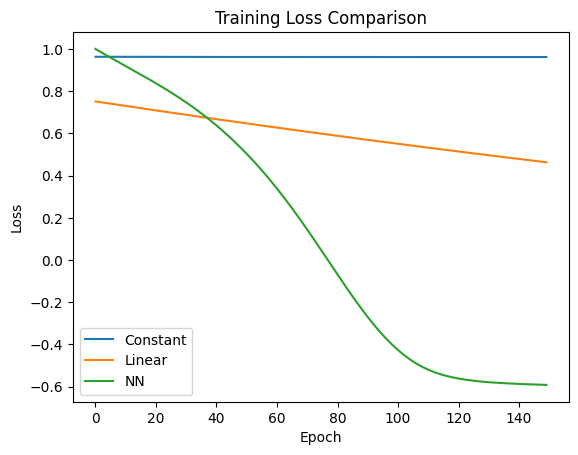

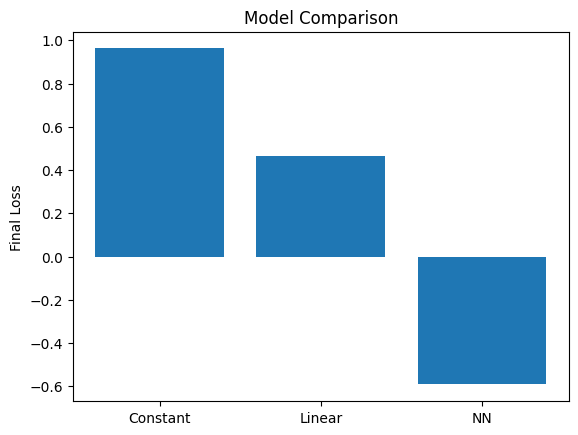

Comparison complete: Constant vs Linear vs NN


In [14]:
plt.figure()
for name, losses in loss_histories.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()


plt.figure()
names = list(final_losses.keys())
values = list(final_losses.values())
plt.bar(names, values)
plt.ylabel("Final Loss")
plt.title("Model Comparison")
plt.show()

print("Comparison complete: Constant vs Linear vs NN")